Vamos a ver cómo funcionan los modelos de visión para clasificar imágenes de perros y gatos.

Torchvision es una librería para trabajar con modelos de visión, Pillow es una librería para trabajar con imágenes en Python y Matplot-lib es una librería para visualizar datos.

In [239]:
%pip install torch torchvision pillow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [240]:
import numpy as np
import matplotlib.pyplot as plt

import torch

from PIL import Image

from torchvision import transforms

from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights
)

1. Cargar el modelo preentrenado:

MobileNetV2 es una CNN ya entrenada:
Ha visto millones de imágenes.

In [241]:
weights = MobileNet_V2_Weights.DEFAULT

model = mobilenet_v2(weights=weights)

#Es para evaluarlo, no para entrenarlo, por eso se pone en modo evaluación
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
  

2. Seleccionamos una imagen:

(np.float64(-0.5), np.float64(650.5), np.float64(470.5), np.float64(-0.5))

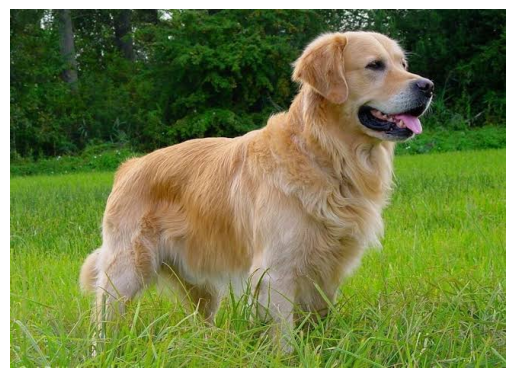

In [242]:
# Cargar la imagen
img = Image.open("fotos/perro.jpg")
#img = Image.open("perro2.jpg")

plt.imshow(img)
plt.axis("off")

3. Preparamos la imagen para que el modelo la pueda entender: los modelos no ven la imagen, sino una matriz numérica.

La CNN espera:

- Tamaño concreto.
- Formato concreto.
- Valores normalizados.

In [243]:
preprocess = weights.transforms()

input_tensor = preprocess(img)

input_batch = input_tensor.unsqueeze(0) # añadimos una dimension->tensor

In [244]:
print(weights.meta)

{'num_params': 3504872, 'min_size': (1, 1), 'categories': ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', '

4. Inferencia.

- La imagen atraviesa todas las capas de la red neuronal.

- La salida son miles de puntuaciones.

- Una por cada categoría conocida.

In [245]:
with torch.no_grad():
    output = model(input_batch)

5. Mostramos el resultado:

In [246]:
predicted_class = output.argmax().item()

predicted_label = (
    weights.meta["categories"][
        predicted_class
    ]
)

print(
    f"Predicción: {predicted_label}"
)

Predicción: golden retriever


# Ejercicio 1 — Cambiar la imagen

En el ejemplo hemos utilizado una imagen proporcionada en el notebook.

Ahora busca una imagen diferente y realiza el proceso completo:

1. Cargar la imagen.
2. Mostrarla.
3. Preprocesarla.
4. Pasarla por el modelo.
5. Obtener la clase predicha.



In [247]:
weights = MobileNet_V2_Weights.DEFAULT

model = mobilenet_v2(weights=weights)

#Es para evaluarlo, no para entrenarlo, por eso se pone en modo evaluación
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
  

(np.float64(-0.5), np.float64(1599.5), np.float64(899.5), np.float64(-0.5))

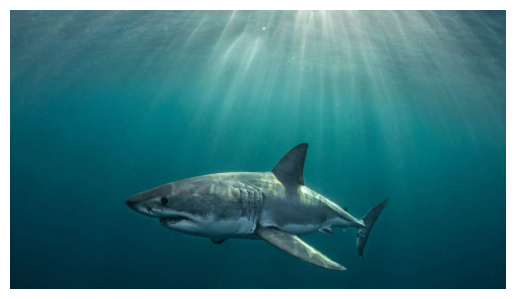

In [248]:
# Cargar la imagen
#img = Image.open("fotos/perro.jpg")
#img = Image.open("fotos/dachshund.jpg")
#img = Image.open("fotos/pitbull.jpg")
#img = Image.open("fotos/goldfish.jpeg")
#img = Image.open("fotos/pez-payaso.jpg")
#img = Image.open("fotos/pollo.jpg")
#img = Image.open("fotos/white-shark.jpeg")
img = Image.open("fotos/white-shark.webp")
plt.imshow(img)
plt.axis("off")

In [249]:
preprocess = weights.transforms()

input_tensor = preprocess(img)

input_batch = input_tensor.unsqueeze(0) # añadimos una dimension->tensor

In [250]:
with torch.no_grad():
    output = model(input_batch)

In [251]:
predicted_class = output.argmax().item()

predicted_label = (
    weights.meta["categories"][
        predicted_class
    ]
)

print(
    f"Predicción: {predicted_label}"
)

Predicción: great white shark


## Preguntas

- ¿Qué ha predicho el modelo?
    
    En las dos primeras imagenes seleccionados ha predicho dos razas muy parecidas y en la tercera la raza en concreto.
- ¿La predicción es correcta?
    
    En las dos primeras estimaciones no, aunque son razas parecidas. En la tercera opciones si es correcta
- ¿La imagen es adecuada para este modelo?
    
    Si,he intentado mantener la misma estructura en las tres imagenes
Prueba al menos con **3 imágenes diferentes**.

# Ejercicio 2 — Las 5 predicciones principales

Hasta ahora nos hemos quedado únicamente con la clase que tiene la puntuación más alta:

```python
predicted_class = output.argmax().item()

In [252]:
# Convertir las salidas del modelo en probabilidades
probabilidad = torch.softmax(output, dim=1)

# Obtener las 5 predicciones principales
values, indices = torch.topk(probabilidad[0], k=5)

# Obtener los nombres de las clases
categories = weights.meta["categories"]

# Mostrar resultados
for i in range(5):
    class_index = indices[i].item()
    class_name = categories[class_index]
    score = values[i].item()

    print(f"{i + 1}. {class_name}: {score:.2%}")

1. great white shark: 60.45%
2. tiger shark: 7.16%
3. hammerhead: 2.32%
4. sturgeon: 1.11%
5. killer whale: 0.60%


# Ejercicio 3 — Comparar imágenes

Selecciona 5 imágenes diferentes.

Para cada una:

1. Ejecuta el modelo.
2. Obtén las 5 predicciones principales.
3. Indica cuál consideras que es la predicción más adecuada.

Crea una tabla resumen:

| Imagen | Predicción 1 | Puntuación | ¿Correcta? |
|---|---|---|---|
| Goldfish | goldfish | 39.70% | Sí |
| dachshund | vizsla | 10.80% | No |
| anemone-fish | anemone-fish | 42.55% | Sí |
| pollo | goldfish | 4.96% | No |
| white-shark| greate white shark | 33.78% | Sí

## Conclusión

¿En qué tipo de imágenes funciona mejor el modelo?

En las pruebas realizadas, ha mostrado mejores condiciones con imagenes mas claras.

¿En cuáles presenta más dificultades?

En las que no tenga la categoria entrenada, enprincipio, mediante "weights.meta", sabemos como ha sifo entrenada, aquellas categorias que no tenga buscara patrones parecidos como es el caso de "Dachsund", don la raza dada es muy parecida.
